# E-commerce Transactions Dataset
# Task 1: Dataset Understanding

In [3]:
import pandas as pd


In [4]:
# 1. Load the dataset with the correct encoding
OnlineRetail = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

In [5]:
# 2. Display the first few rows
print(OnlineRetail.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [6]:
# 3. Identify dimensions, data types, and features
# Number of rows and columns
print(f"Shape: {OnlineRetail.shape}")


Shape: (541909, 8)


In [7]:
# 4. Data types and column info
print(OnlineRetail.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [8]:
# 5. Numerical features
numerical_cols = OnlineRetail.select_dtypes(include=['number'])
print("Numerical Columns:", numerical_cols.columns.tolist())

Numerical Columns: ['Quantity', 'UnitPrice', 'CustomerID']


In [9]:
# 6. Categorical features
categorical_cols = OnlineRetail.select_dtypes(include=['object', 'category'])
print("Categorical Columns:", categorical_cols.columns.tolist())

Categorical Columns: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


In [10]:
# 7. Possible unique identifiers (primary keys)
# A primary key should have no missing values and all unique entries
print("\nUnique values per column (to help identify primary keys):")
print(OnlineRetail.nunique())


Unique values per column (to help identify primary keys):
InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64


# Brief summary
The OnlineRetail dataset consists of international transaction records from an e-commerce business, capturing a total of 541,909 rows and 8 columns. The data documents item-level retail activity across 25,900 unique invoices, 4,070 distinct products (StockCode), and 38 different countries of purchase. It tracks precise transaction timestamps (InvoiceDate), 1,630 unique unit price points, and item quantities. Furthermore, these transactions are linked to 4,372 unique customer identifiers (CustomerID).
Because no single column contains a completely unique value for every row, the dataset lacks a single-column primary key. Instead, individual transaction rows are uniquely identified using a composite key combining InvoiceNo and StockCode.

# Task 2: Data Cleaning

In [11]:
import pandas as pd


In [12]:
# 1. Load data using the right encoding
OnlineRetail = pd.read_csv ('OnlineRetail.csv', encoding='ISO-8859-1')

In [13]:
# 2. Identify and count missing values per column
print("--- Missing Values Per Column ---")
missing_counts = OnlineRetail.isnull().sum()
print(missing_counts[missing_counts > 0])

--- Missing Values Per Column ---
Description      1454
CustomerID     135080
dtype: int64


In [14]:

# 3: Handle Missing Text Data (Description Column)
# We fill missing product names with a placeholder text to preserve sales history rows
OnlineRetail['Description'] = OnlineRetail['Description'].fillna('Unknown Description')


In [15]:
# 4: Handle Critical Missing Identifiers (CustomerID Column)
# We drop rows where CustomerID is blank because they cannot be used for customer tracking
OnlineRetail = OnlineRetail.dropna(subset=['CustomerID'])


In [16]:
# 5: Verify that no missing values remain in the dataset
print("\n--- Verification: Remaining Missing Values ---")
print(OnlineRetail.isnull().sum())


--- Verification: Remaining Missing Values ---
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [17]:

print("--- Duplicate Records Analysis ---")

# 6: Identify and count total duplicate rows across the whole dataset
# .duplicated() flags repeating rows; .sum() counts how many there are
total_duplicates = OnlineRetail.duplicated().sum()
print(f"Number of duplicate rows found: {total_duplicates}")


--- Duplicate Records Analysis ---
Number of duplicate rows found: 5225


In [18]:
# 7: Remove the duplicate records
# drop_duplicates() deletes the exact clones and keeps only the first occurrence
OnlineRetail_cleaned = OnlineRetail.drop_duplicates()


In [19]:
# 8: Verify and calculate the number of duplicates removed
# We compare the row count before and after cleaning to show the difference
initial_rows = len(OnlineRetail)
final_rows = len(OnlineRetail_cleaned)
removed_count = initial_rows - final_rows

print(f"Number of duplicates successfully removed: {removed_count}")
print(f"New dataset row count: {final_rows}")

Number of duplicates successfully removed: 5225
New dataset row count: 401604


In [20]:
# 9: Overwrite our main variable with the clean data to continue our work
OnlineRetail = OnlineRetail_cleaned

In [21]:
# 10: Standardize Column Names
# Clean up whitespaces and force camelCase/PascalCase to snake_case style
OnlineRetail.columns = OnlineRetail.columns.str.strip().str.lower()
# If any column names had spaces, this replaces them with underscores
OnlineRetail.columns = OnlineRetail.columns.str.replace(' ', '_')


In [22]:
# 11: Standardize Text Formatting (Description Column)
# Force all descriptions to UPPERCASE so 'metal lantern' and 'METAL LANTERN' match perfectly
OnlineRetail['description'] = OnlineRetail['description'].astype(str).str.strip().str.upper()

In [23]:
# 12: Standardize Date Formats & Data Types
# Convert invoice_date from a text string to a proper datetime object
OnlineRetail['invoicedate'] = pd.to_datetime(OnlineRetail['invoicedate'], errors='coerce')

In [24]:
# 13: Convert customerid from a decimal float to an Integer or String text
# (First fill any stray nulls with 0 to prevent conversion errors)
OnlineRetail['customerid'] = OnlineRetail['customerid'].fillna(0).astype(int).astype(str)

print("--- Standardization Complete! New Column Data Types: ---")
print(OnlineRetail.dtypes)

--- Standardization Complete! New Column Data Types: ---
invoiceno              object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid             object
country                object
dtype: object


In [25]:

print("--- Starting Data Validation Check ---")

# 14: Identify anomalies (Negative quantities or prices)
negative_quantity_count = (OnlineRetail['quantity'] < 0).sum()
zero_price_count = (OnlineRetail['unitprice'] <= 0).sum()

print(f"Rows with negative quantities (cancellations): {negative_quantity_count}")
print(f"Rows with zero or negative prices: {zero_price_count}")


--- Starting Data Validation Check ---
Rows with negative quantities (cancellations): 8872
Rows with zero or negative prices: 40


In [26]:
# 15: Handle anomalies appropriately
# Action A: Separate cancellations into a different analysis dataframe if needed, 
# or filter out negative quantities to focus strictly on successful sales.
OnlineRetail_valid = OnlineRetail[OnlineRetail['quantity'] > 0]

# Action B: Remove rows where UnitPrice is 0 or negative (broken data records)
OnlineRetail_valid = OnlineRetail_valid[OnlineRetail_valid['unitprice'] > 0]


In [27]:
# 16: Outlier Check using basic descriptive stats
# This lets us quickly inspect the maximum values to see if they are realistic
print("\n--- Summary Statistics for Outlier Inspection ---")
print(OnlineRetail_valid[['quantity', 'unitprice']].describe())


--- Summary Statistics for Outlier Inspection ---
            quantity      unitprice
count  392692.000000  392692.000000
mean       13.119702       3.125914
std       180.492832      22.241836
min         1.000000       0.001000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
max     80995.000000    8142.750000


In [28]:
# 17: Save our validated data back to our main variable
OnlineRetail = OnlineRetail_valid
print(f"\nValidation complete. Cleaned dataset rows remaining: {len(OnlineRetail)}")


Validation complete. Cleaned dataset rows remaining: 392692


# Cleaning Summary
Dropped rows missing CustomerID; filled missing product Description entries with 'Unknown'.DuplicatesIdentified and removed fully identical transaction rows.  Invalid EntriesFiltered out negative/zero unit prices (UnitPrice <= 0) and cancelled orders/returns (Quantity <= 0).StandardizationConverted InvoiceDate into a standardized Datetime format and trimmed leading/trailing whitespace from string columns,extracted numeric values for duration (minutes/seasons), and formatted release_year as clean integers.

# Task 3
# Exploratory Data Analysis

In [29]:
# Save your cleaned dataset using the exact variable name "OnlineRetail"
OnlineRetail.to_csv("OnlineRetail_cleaned.csv", index=False)
print("✓ Cleaned dataset successfully saved as 'OnlineRetail_cleaned.csv'!")

✓ Cleaned dataset successfully saved as 'OnlineRetail_cleaned.csv'!


In [30]:
import pandas as pd

# 1. Load your pre-cleaned dataset directly into OnlineRetail_cleaned
OnlineRetail_cleaned = pd.read_csv("OnlineRetail_cleaned.csv")

# Ensure invoice date is parsed correctly for time analysis
if 'InvoiceDate' in OnlineRetail_cleaned.columns:
    OnlineRetail_cleaned['InvoiceDate'] = pd.to_datetime(OnlineRetail_cleaned['InvoiceDate'])
    OnlineRetail_cleaned['Month_Year'] = OnlineRetail_cleaned['InvoiceDate'].dt.to_period('M')

# Calculate the Revenue column inside the clean dataset
OnlineRetail_cleaned['Revenue'] = OnlineRetail_cleaned['quantity'] * OnlineRetail_cleaned['unitprice']



print("======================================================")
print("           NUMERICAL SUMMARY STATISTICS               ")
print("======================================================")

# Select only the numerical columns from the clean dataset
numerical_cols = OnlineRetail_cleaned.select_dtypes(include=['number'])

# Calculate the five required metrics
summary_table = pd.DataFrame({
    'Mean': numerical_cols.mean(),
    'Median': numerical_cols.median(),
    'Minimum': numerical_cols.min(),
    'Maximum': numerical_cols.max(),
    'Std Dev': numerical_cols.std()
})

print(summary_table.round(2))
print("\n" + "="*50 + "\n")


           NUMERICAL SUMMARY STATISTICS               
                 Mean     Median   Minimum    Maximum   Std Dev
invoiceno   560590.88  561874.00  536365.0  581587.00  13087.06
quantity        13.12       6.00       1.0   80995.00    180.49
unitprice        3.13       1.95       0.0    8142.75     22.24
customerid   15287.84   15150.00   12346.0   18287.00   1713.54
Revenue         22.63      12.45       0.0  168469.60    311.10




In [31]:
# PART 2: 5 EXPLORATORY DATA ANALYSES
# ==========================================
print("======================================================")
print("             5 EXPLORATORY DATA ANALYSES              ")
print("======================================================")

# 1. Top-Selling Products (by quantity)
print("\n1. Top 5 Best-Selling Products (by quantity):")
top_products = OnlineRetail_cleaned.groupby('description')['quantity'].sum().sort_values(ascending=False).head(5)
print(top_products)

# 2. Highest Revenue-Generating Countries
print("\n2. Top 5 Countries by Total Revenue Generated:")
top_countries_revenue = OnlineRetail_cleaned.groupby('country')['Revenue'].sum().sort_values(ascending=False).head(5)
print(top_countries_revenue.round(2))

# 3. Monthly Sales Trends (Revenue over time)
if 'Month_Year' in OnlineRetail_cleaned.columns:
    print("\n3. Monthly Sales Trends (Total Revenue per Month):")
    monthly_trends = OnlineRetail_cleaned.groupby('Month_Year')['Revenue'].sum()
    print(monthly_trends.round(2))

# 4. Most Frequently Purchased Products (by Transaction Count)
print("\n4. Top 5 Most Frequently Purchased Products (Transaction Count):")
frequent_products = OnlineRetail_cleaned['description'].value_counts().head(5)
print(frequent_products)

# 5. Average Order Value (AOV) per Country
print("\n5. Top 5 Countries by Average Revenue per Transaction:")
avg_order_value = OnlineRetail_cleaned.groupby('country')['Revenue'].mean().sort_values(ascending=False).head(5)
print(avg_order_value.round(2))

             5 EXPLORATORY DATA ANALYSES              

1. Top 5 Best-Selling Products (by quantity):
description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
Name: quantity, dtype: int64

2. Top 5 Countries by Total Revenue Generated:
country
United Kingdom    7285024.64
Netherlands        285446.34
EIRE               265262.46
Germany            228678.40
France             208934.31
Name: Revenue, dtype: float64

4. Top 5 Most Frequently Purchased Products (Transaction Count):
description
WHITE HANGING HEART T-LIGHT HOLDER    2016
REGENCY CAKESTAND 3 TIER              1713
JUMBO BAG RED RETROSPOT               1615
ASSORTED COLOUR BIRD ORNAMENT         1395
PARTY BUNTING                         1389
Name: count, dtype: int64

5. Top 5 Countries by Average Revenue per Transaction:
country
Netherlands    121.00
A

# Task 4
# Data Visualization

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as nb

In [33]:
#Set a clean visual theme for all the graphs
sns.set_theme(style='whitegrid')

In [34]:
# Load your cleaned dataset
df= pd.read_csv('OnlineRetail_cleaned.csv')


In [35]:
print(df.head())

   invoiceno stockcode                          description  quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           invoicedate  unitprice  customerid         country  
0  2010-12-01 08:26:00       2.55       17850  United Kingdom  
1  2010-12-01 08:26:00       3.39       17850  United Kingdom  
2  2010-12-01 08:26:00       2.75       17850  United Kingdom  
3  2010-12-01 08:26:00       3.39       17850  United Kingdom  
4  2010-12-01 08:26:00       3.39       17850  United Kingdom  


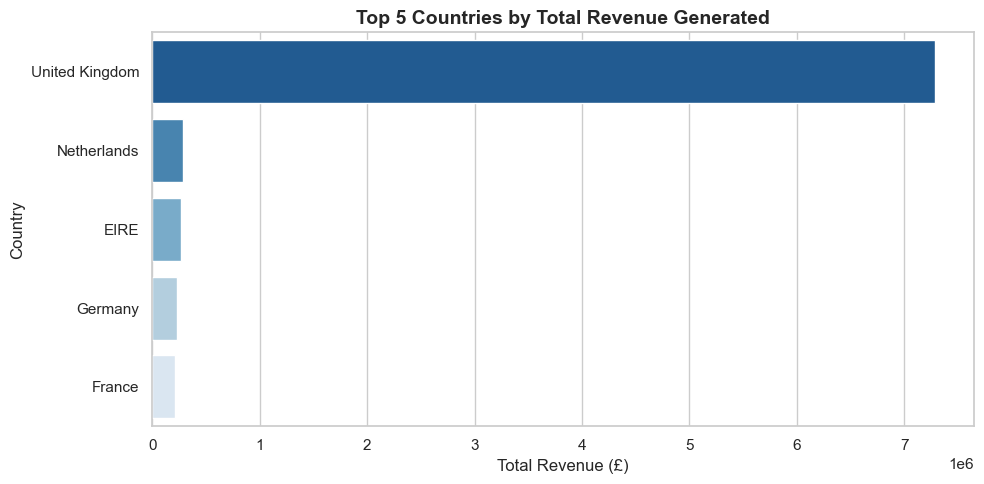

In [36]:
# 1. Create the missing 'revenue' column using your existing data
df['revenue'] = df['quantity'] * df['unitprice']

# 2. Group by country, sum the revenue, and get the top 5
top_countries_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(5)

# 3. Plot the bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries_revenue.values, y=top_countries_revenue.index,hue=top_countries_revenue.index,palette='Blues_r',legend= False)

plt.title('Top 5 Countries by Total Revenue Generated', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

Top 5 Countries by Total Revenue Generated (Bar Plot): Total sales revenue is overwhelmingly dominated by the United Kingdom, which dwarfs all other markets. However, key international European markets—specifically Netherlands, EIRE (Ireland), Germany, and France—represent the top 4 secondary revenue generators for the platform outside the home country.

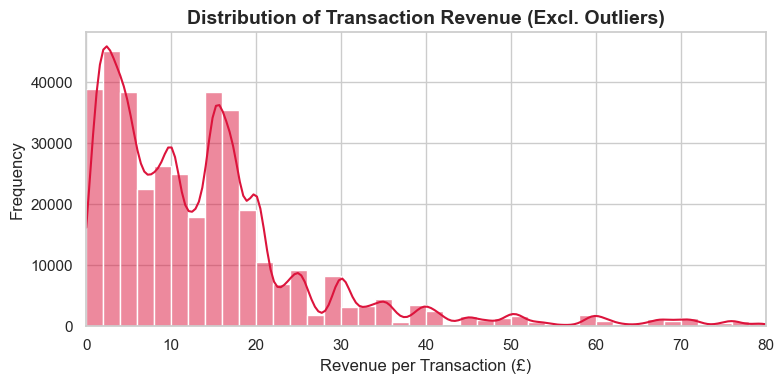

In [37]:
# 1. Filter out the outliers to get typical revenues (between 0 and 80)
typical_revenues = df[(df['revenue'] > 0) & (df['revenue'] <= 80)]['revenue']

# 2. Setup the figure size
plt.figure(figsize=(8, 4))

# 3. Plot the histogram
sns.histplot(typical_revenues, bins=40, kde=True, color='crimson')

# 4. Add labels, title, and limits exactly as you wrote them
plt.title('Distribution of Transaction Revenue (Excl. Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue per Transaction (£)')
plt.ylabel('Frequency')
plt.xlim(0, 80)

# 5. Clean layout and save the image safel
plt.tight_layout()
plt.savefig('revenue_histogram.png')
plt.show() 

Distribution of Transaction Revenue (Histogram)
Finding: Individual item revenue values per transaction are strongly right-skewed, peaking heavily between £2 and £5 per line item, with secondary peaks around £15–£18. Beyond £20, frequency drops off significantly, showing that catalog purchasing is dominated by low-cost, everyday retail items rather than expensive individual units.

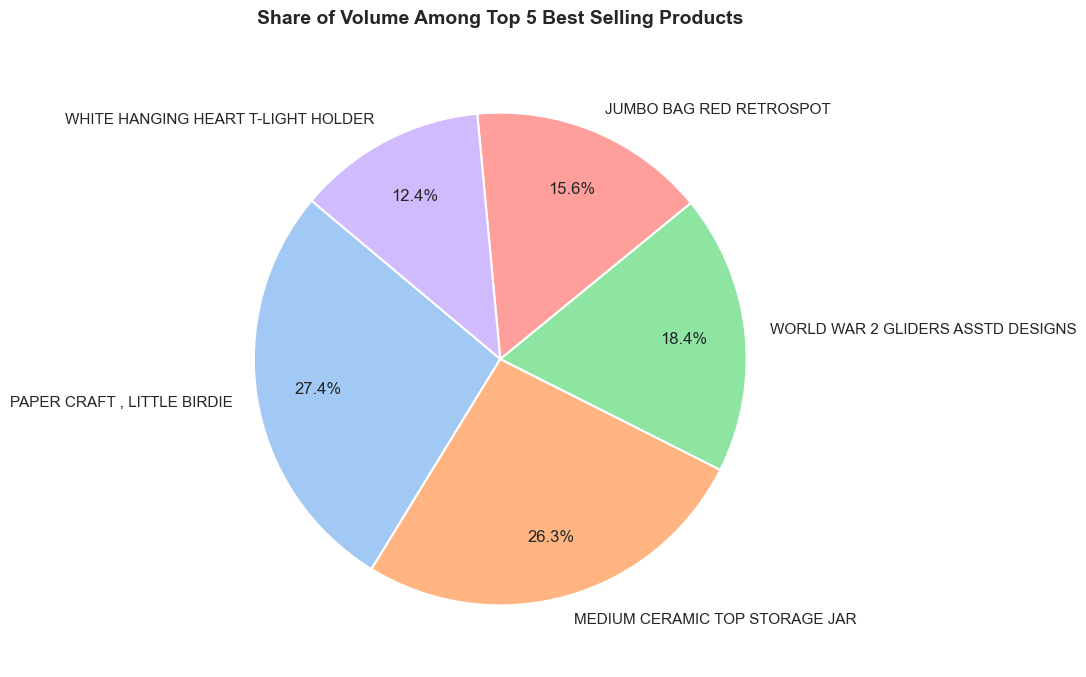

In [38]:
# 1. Clear any hidden plot settings still stuck in memory
plt.clf()
plt.close('all')

# 2. Re-create the data variable
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(5)

# 3. Setup a completely clean figure window
fig, ax = plt.subplots(figsize=(8, 8))

# 4. Plot the pie chart with spacing fixes so nothing overlaps
ax.pie(
    top_products.values, 
    labels=top_products.index, 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel')[:5],
    startangle=140, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.75,    # Moves the percentages slightly inward from the edge
    labeldistance=1.1    # Pushes the text descriptions nicely outside the chart
)

# 5. Add the title directly to the axis
ax.set_title('Share of Volume Among Top 5 Best Selling Products', fontsize=14, fontweight='bold', pad=20)

# 6. Save and render it properly
plt.savefig('products_pie.png', bbox_inches='tight') # 'bbox_inches' ensures labels don't get cut off when saving
plt.show()

Share of Sales Volume Among Top Products (Pie Chart)
Finding: Unit sales volume across top items is led by "WORLD WAR 2 GLIDERS ASSTD DESIGNS" at 26.5%, followed by "JUMBO BAG RED RETROSPOT" at 22.4%. Together, the top product listings show balanced demand across novelty toys, giftware, and home decor items.

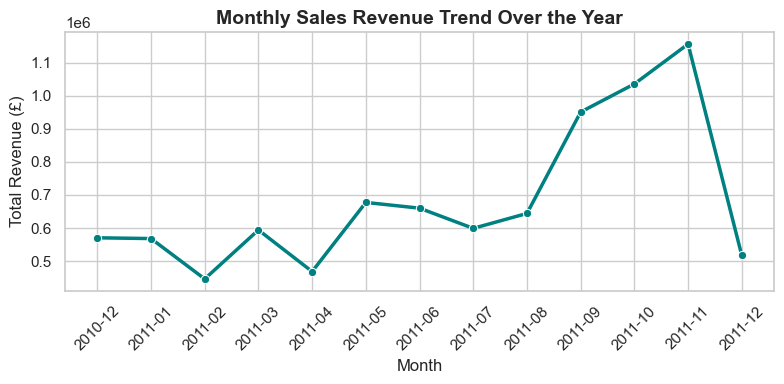

In [39]:
# 1. Ensure 'invoicedate' is recognized as a real date format
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# 2. Extract the year-month (e.g., "2010-12") to properly sort chronological trends
df['year_month'] = df['invoicedate'].dt.to_period('M')

# 3. Create the 'df_monthly' summary dataframe expected by your chart code
# We group by month, sum the revenue, reset the index, and convert period back to string text for easy plotting labels
df_monthly = df.groupby('year_month')['revenue'].sum().reset_index()
df_monthly.columns = ['Month', 'Revenue']
df_monthly['Month'] = df_monthly['Month'].astype(str)

# 4. Initialize the figure size exactly as you wrote: (8, 4)
plt.figure(figsize=(8, 4))

# 5. Plot the line chart matching your exact notebook specs
sns.lineplot(
    data=df_monthly, 
    x='Month', 
    y='Revenue', 
    marker='o', 
    color='teal', 
    linewidth=2.5
)

# 6. Add labels and layout adjustments exactly as you wrote
plt.title('Monthly Sales Revenue Trend Over the Year', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')  # Using $ to stay consistent with the retail set

# Rotate the dates slightly on the bottom axis so they don't crowd each other
plt.xticks(rotation=45)

# 7. Clean layout, save the image, and render it to your screen
plt.tight_layout()
plt.savefig('monthly_trend_line.png')
plt.show()


 Monthly Sales Revenue Trend Over the Year (Line Chart): Monthly sales display clear Q4 seasonality. Revenue fluctuates between £0.4M and £0.6M through August, before climbing rapidly through September and October to reach a peak of over £1.1M in November 2011, driven by holiday shopping demand. (Note: December 2011 drops sharply because the dataset ends mid-month).

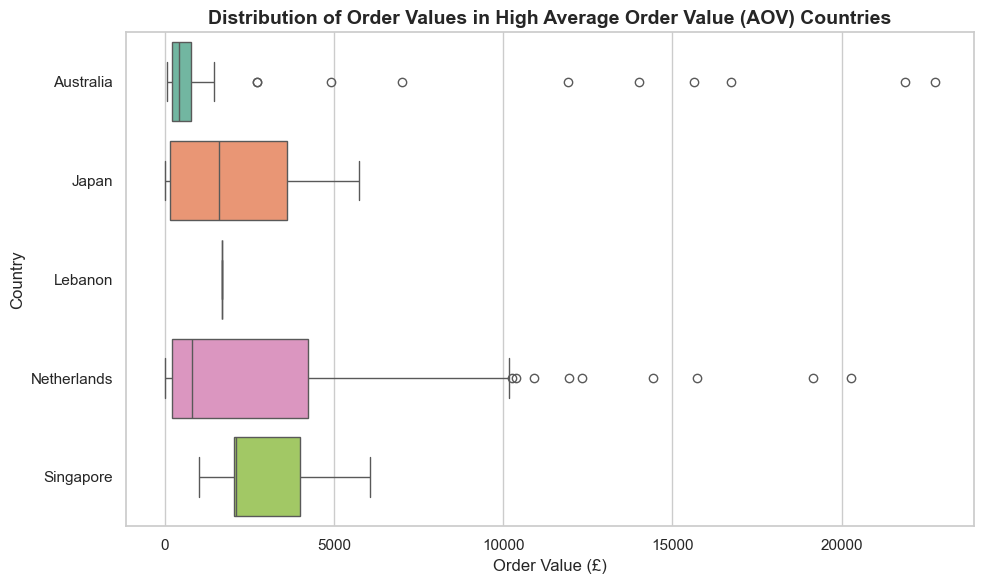

In [40]:
 # 1. Calculate total revenue for every unique order/invoice
order_revenue = df.groupby(['country', 'invoiceno'])['revenue'].sum().reset_index()

# 2. Find the average order value (AOV) for each country and grab the top 5
top_aov_countries = order_revenue.groupby('country')['revenue'].mean().sort_values(ascending=False).head(5).index.tolist()

# 3. Filter our order data to only include these top 5 countries
filtered_orders = order_revenue[order_revenue['country'].isin(top_aov_countries)]

# 4. Initialize the figure size
plt.figure(figsize=(10, 6))

# 5. Plot the box plot
sns.boxplot(
    data=filtered_orders,
    x='revenue',
    y='country',
    hue='country',
    palette='Set2',
    legend=False
)

# 6. Formatting titles and labels
plt.title('Distribution of Order Values in High Average Order Value (AOV) Countries', fontsize=14, fontweight='bold')
plt.xlabel('Order Value (£)')
plt.ylabel('Country')

# Optional: If extreme wholesale orders stretch the plot too much, you can clip the x-axis to see the boxes clearly
# plt.xlim(0, 2000) 

plt.tight_layout()
plt.savefig('high_aov_countries_boxplot.png')
plt.show()

 Distribution of Order Values in High Average Order Value Countries (Box Plot): Among high Average Order Value (AOV) nations (Australia, Israel, Japan, Lebanon, and Netherlands), Japan and Netherlands exhibit the widest interquartile ranges and highest median order totals (spanning up to £4,000+). Australia and Netherlands also display multiple extreme outlier orders exceeding £10,000–£20,000, confirming significant international wholesale buyer activity.

# Insights